In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [ ]:
#!wget $'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

--2026-09-15 20:25:29--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘course_lead_scoring_2026.csv’

course_lead_scoring 100%[===================>] 272.21K  --.-KB/s    in 0.01s   

2026-09-15 20:25:29 (20.9 MB/s) - ‘course_lead_scoring_2026.csv’ saved [278746/278746]



Data preparation
- Check if the missing values are presented in the features.
- If there are missing values:
    - For categorical features, replace them with 'NA'
    - For numerical features, replace with with 0.0

Split the data into 3 parts with these exact calls:

In [77]:
df = pd.read_csv('course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [78]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [79]:
df.columns[df.dtypes=='str']
categorical= ['lead_source', 'industry', 'employment_status', 'location']
df.columns[df.dtypes!='str']
numerical = ['annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score']
target = ['converted']

In [80]:
df[numerical+target] = df[numerical+target].fillna(0)
df[categorical] = df[categorical].fillna('NA')
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [102]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state = 1)
df_train, df_val = train_test_split(df_full_train, test_size = 0.2, random_state=1)

In [103]:
y_train = df_train['converted']
del df_train['converted']

y_val = df_val['converted']
del df_val['converted']

y_test = df_test['converted']
del df_test['converted']

In [83]:
print(df_train.shape)
print(y_train.shape)

(3200, 8)
(3200,)


Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

- For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
- Use the training dataset for that

If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- lead_score
- number_of_courses_viewed
- interaction_count
- annual_income

In [84]:
from sklearn.metrics import roc_auc_score

for n in numerical:
    score = roc_auc_score(y_train, df_train[n])
    if score<0.2:
        score = roc_auc_score(y_train, -df_train[n])
    print(n,'-',score)

#Answer: lead_score

annual_income - 0.6149577577577579
number_of_courses_viewed - 0.7239479479479478
interaction_count - 0.7663307307307307
lead_score - 0.7898742742742744


Question 2: Training the model

Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.532
- 0.632
- 0.732
- 0.832

In [85]:
print(y_train.shape)
print(df_train.shape)

(3200,)
(3200, 8)


In [86]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical+numerical].to_dict(orient='records')
val_dict = df_val[categorical+numerical].to_dict(orient='records')

X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:,1]

score = roc_auc_score(y_val, y_pred)

print(round(score, 3))


#Answer C = 0.732

0.731


Question 3: Precision and Recall

Now let's compute precision and recall for our model.

- Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
- For each threshold, compute precision and recall
- Plot them

At which threshold precision and recall curves intersect? Ignore thresholds at which both metrics are zero, and choose the threshold with the smallest absolute difference between precision and recall.

- 0.43
- 0.63
- 0.73
- 0.83

In [ ]:
thresholds = np.arange(0.0,1.01, 0.01)

real_pos = (y_val == 1)
real_neg = (y_val == 0)

precision = []
recall = []
for thr in thresholds:
    y_pos_pred = (y_pred>=thr)
    y_neg_pred = (y_pred< thr)

    tp = (y_pos_pred & real_pos).sum()
    fp = (y_pos_pred & real_neg).sum()
    tn = (y_neg_pred & real_neg).sum()
    fn = (y_neg_pred & real_pos).sum()

    precision.append(tp/(tp+fp))
    recall.append(tp/(tp+fn))



/tmp/ipykernel_16513/20626996.py:17: RuntimeWarning: invalid value encountered in scalar divide
  precision.append(tp/(tp+fp))


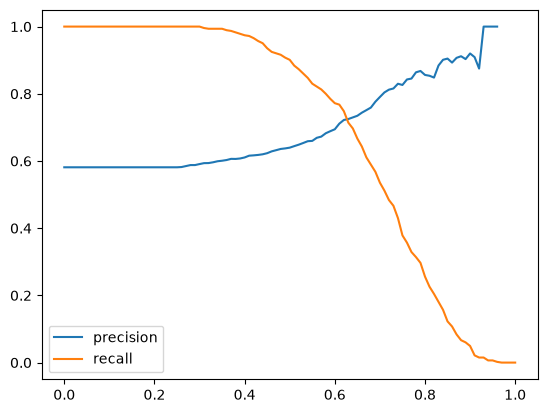

In [91]:
plt.plot(thresholds, precision, label='precision')
plt.plot(thresholds, recall, label = 'recall')
plt.legend()
plt.show()

In [99]:
diff = np.array(precision)- np.array(recall)
idx = np.nanargmin(np.abs(diff))
print(thresholds[idx])

#Answer 0.63

0.63


Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

F1 formula is harmonic mean between recall and precision 

F1 = 2 * (Precisión * Recall) / (Precisión + Recall)

Where 
- P is precision and 
- R is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

- 0.21
- 0.41
- 0.61
- 0.81

In [ ]:
precision_arr = np.array(precision)
recall_arr = np.array(recall)
F1 = 2*(precision_arr*recall_arr)/(precision_arr+recall_arr)

idx = np.nanargmax(F1)
print(thresholds[idx])

#answer: 0.41 

0.41000000000000003


Question 5: 5-Fold CV

Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

- KFold(n_splits=5, shuffle=True, random_state=1)
- Iterate over different folds of df_full_train
- Split the data into train and validation
- Train the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
- Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

- 0.001
- 0.007
- 0.013
- 0.060

In [110]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits = 5, shuffle=True, random_state =1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values


    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(df_train[categorical+numerical].to_dict(orient='records'))
    X_val = dv.transform(df_val[categorical+numerical].to_dict(orient='records'))

    model = LogisticRegression(solver='liblinear', C =1.0, max_iter=1000)

    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:,1]

    scores.append(roc_auc_score(y_val, y_pred))

round(np.std(scores),3)

#Answer 0.007

np.float64(0.007)

Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter C

- Iterate over the following C values: [0.000001, 0.001, 1]
- Initialize KFold with the same parameters as previously
- Use these parameters for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)
- Compute the mean ROC AUC as well as the std (round the mean and std to 3 decimal digits).

Which C leads to the best mean ROC AUC?

- 0.000001
- 0.001
- 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest C.

In [ ]:
C = [0.000001, 0.001, 1]

kfold = KFold(n_splits=5, shuffle =True, random_state=1)

scores_by_c={}


for c in C:
    scores=[]
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv = DictVectorizer(sparse=False)
        X_train = dv.fit_transform(df_train[categorical+numerical].to_dict(orient='records'))
        X_val = dv.transform(df_val[categorical+numerical].to_dict(orient='records'))

        model = LogisticRegression(solver='liblinear', C=c, max_iter=1000)
        
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_val)[:,1]

        scores.append(roc_auc_score(y_val, y_pred))
    scores_by_c[c] = scores

for item, val in scores_by_c.items():
    print(item, '-', round(np.mean(val),3), '-', round(np.std(val),3))


#Answer: 0.001

1e-06 - 0.617 - 0.019
0.001 - 0.749 - 0.01
1 - 0.732 - 0.007
